In [1]:
%load_ext autoreload
%autoreload 2
import os
import h5py
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import models
import wandb

import sys
sys.path.append('../../../../src/utils/')
sys.path.append('../../../../src/benchmark/')
from build_model import resnet50_, resnet34_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs, train, valid
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from RotateConvolution import RotateConv2d

In [2]:
# with h5py.File('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', 'r') as h5:
#     viz_h5_structure(h5)
num_workers = 8
batch_size = 5000
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('/mnt/raid0/yichen/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
# viz_dataloader(train_dl, label_converter=label_converter, title='imagenet-train-10m')

valid_dl = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
# viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet-valid-2m')

# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('../../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
# viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

# noise-cv-2m
cv_noise_ds_2m = hdf5_dataset('../../../../datasets/noise_v4_rot_2m-test.h5', folder='test', transform=transforms.ToTensor())
cv_noise_dl_2m = DataLoader(cv_noise_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
# viz_dataloader(cv_noise_dl_2m, label_converter=label_converter, title='noise-cv-2m')

In [3]:
class multikernel_resnet34_(nn.Module):
    def __init__(self, in_channels, n_classes, dropout, kernel_sizes):
        super(multikernel_resnet34_, self).__init__()
        self.model_list = nn.ModuleList()
        for kernel_size in kernel_sizes:
            model = resnet34_(in_channels=in_channels, n_classes=n_classes, dropout=dropout)
            model.conv1 = RotateConv2d(in_channels, 64, kernel_size=kernel_size, padding=int(kernel_size/2), stride=4)
            model.fc = nn.Identity()  # Remove the final fully connected layer
            self.model_list.append(model)

        self.classifier = nn.Sequential(nn.BatchNorm1d(2048),
                                        nn.Dropout(p=dropout, inplace=False),
                                        nn.Linear(in_features=2048, out_features=512, bias=False),
                                        nn.ReLU(inplace=True),

                                        nn.BatchNorm1d(512),
                                        nn.Dropout(p=dropout, inplace=False),
                                        nn.Linear(in_features=512, out_features=64, bias=False),
                                        nn.ReLU(inplace=True),
                                        
                                        nn.BatchNorm1d(64),
                                        nn.Dropout(p=dropout, inplace=False),
                                        nn.Linear(in_features=64, out_features=n_classes, bias=True)
                                        )

    def forward(self, x):
        fv_list = [model(x) for model in self.model_list]
        # for f in fv_list:
            # print(f.shape)
        fv = torch.cat(fv_list, dim=1)
        # print(fv.shape)
        return self.classifier(fv)

model = multikernel_resnet34_(in_channels=3, n_classes=17, dropout=0.5, kernel_sizes=[84, 64, 48, 32])
outputs = model(torch.randn(2,3,256,256))
outputs.shape

torch.Size([2, 17])

In [4]:
model = torch.load('../../../../saved_models/ResNet34_MultiKernel_large_rot_conv2d-10m/epoch-11.pt').module
model = model.to(torch.device('cpu'))
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4])
device = torch.device('cuda:0')

torch.Size([2, 17])


In [5]:
wandb.login()
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet34_MultiKernel_large_rot_conv2d-10m'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='preprocess', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [16]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))
                            

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_2m, cv_noise_dl_2m], cv_name_list=['cv_atom_2m', 'cv_noise_2m'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/20


  0%|          | 0/1001 [00:00<?, ?it/s]

100%|██████████| 1001/1001 [3:49:14<00:00, 13.74s/it] 


Training: Loss: 2.0675, Accuracy: 32.4497%.


100%|██████████| 251/251 [31:17<00:00,  7.48s/it]


...

cv_atom_2m: Loss: 4.3718, Accuracy: 11.8337%.


100%|██████████| 250/250 [31:00<00:00,  7.44s/it]


cv_noise_2m: Loss: 4.1567, Accuracy: 12.6372%.
Epoch: 12/20


 57%|█████▋    | 569/1001 [2:08:03<1:37:13, 13.50s/it]


KeyboardInterrupt: 

In [6]:
lr = 1e-3
start = 10
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))
                            

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_2m, cv_noise_dl_2m], cv_name_list=['cv_atom_2m', 'cv_noise_2m'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../../saved_models/{NAME}/', tracking=True)

Epoch: 11/30


  0%|          | 0/1601 [00:00<?, ?it/s]

100%|██████████| 1601/1601 [5:41:10<00:00, 12.79s/it]  


Training: Loss: 0.1125, Accuracy: 98.4108%.


100%|██████████| 401/401 [44:37<00:00,  6.68s/it]


...

100%|██████████| 407/407 [45:24<00:00,  6.69s/it]


cv_atom_2m: Loss: 3.0722, Accuracy: 38.6758%.


100%|██████████| 400/400 [44:57<00:00,  6.74s/it]


cv_noise_2m: Loss: 0.9176, Accuracy: 75.4574%.
Epoch: 25/30


 47%|████▋     | 759/1601 [2:41:23<2:59:18, 12.78s/it]

### cv with atom dataset with added noise on background

In [5]:
import torch
import numpy as np
from torchvision import transforms

class AddRandomNoise(object):
    def __init__(self, intensity=0.1, only_blank_background=False, blank_threshold=0.1):
        """
        Args:
            intensity (float): Intensity of the noise to be added, as a fraction of the maximum pixel value.
            only_blank_background (bool): If True, only add noise to areas with a blank background.
            blank_threshold (float): Threshold to consider a pixel as part of the blank background.
        """
        self.intensity = intensity
        self.only_blank_background = only_blank_background
        self.blank_threshold = blank_threshold

    def __call__(self, img):
        """
        Args:
            img (PIL.Image or torch.Tensor): Image to be transformed.

        Returns:
            Transformed image.
        """

        if self.only_blank_background:
            # Create a mask for areas with a blank background
            blank_mask = (img < self.blank_threshold).all(dim=0)

            # Add noise only to the blank areas
            noise = torch.rand_like(img) * self.intensity
            img = img + noise * blank_mask
        else:
            # Add noise to the entire image
            noise = torch.rand_like(img) * self.intensity
            img = img + noise

        # Clip the values to maintain valid pixel range
        img = torch.clamp(img, 0, 1)

        return img

    def __repr__(self):
        return f'{self.__class__.__name__}(intensity={self.intensity}, only_blank_background={self.only_blank_background}, blank_threshold={self.blank_threshold})'


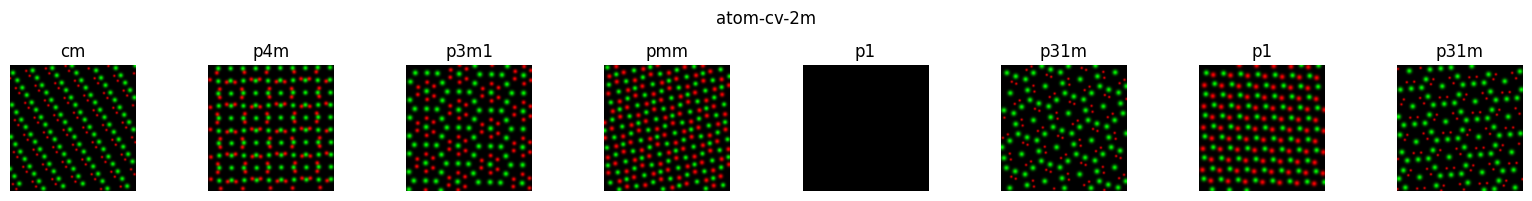

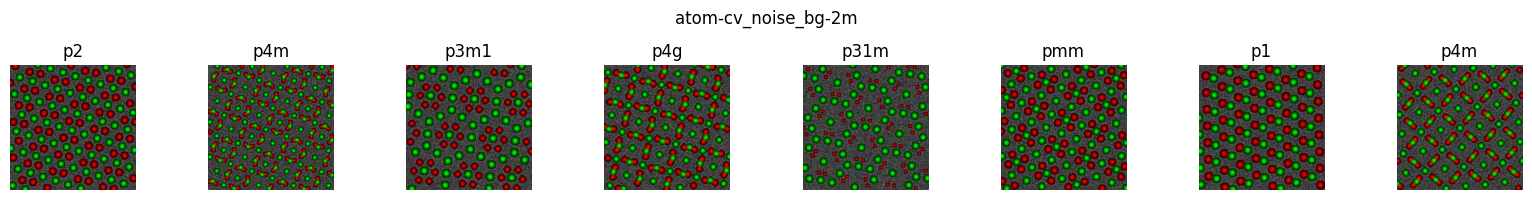

In [30]:
num_workers = 8
batch_size = 64
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)


# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('../../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

# atom-cv-2m
cv_atom_noise_bg_ds_2m = hdf5_dataset('../../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', 
                                      transform=transforms.Compose([transforms.ToTensor(),
                                                                    AddRandomNoise(intensity=0.5, only_blank_background=True, blank_threshold=0.1)]))
cv_atom_noise_bg_dl_2m = DataLoader(cv_atom_noise_bg_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_noise_bg_dl_2m, label_converter=label_converter, title='atom-cv_noise_bg-2m')

In [24]:
model = torch.load('../../../../saved_models/ResNet34_MultiKernel_rot_conv2d-10m/epoch-20.pt').module
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

In [28]:
loss_func = nn.CrossEntropyLoss()
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, cv_atom_dl_2m, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

100%|██████████| 255/255 [23:15<00:00,  5.47s/it]

Validation: Loss: 2.7294, Accuracy: 38.2863%.


In [26]:
loss_func = nn.CrossEntropyLoss()
valid(model, loss_func, device, cv_atom_noise_bg_dl_2m, task_label='valid', tracking=False)

100%|██████████| 31760/31760 [2:43:27<00:00,  3.24it/s]  


(3.11604146016224, 0.33446962298778493)

In [ ]:
num_workers = 8
batch_size = 8000
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('../../../../datasets/atom_v4_rot_2m_fixed.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

# atom-cv-2m
cv_atom_noise_bg_ds_2m = hdf5_dataset('../../../../datasets/atom_v4_rot_2m_fixed.h5', folder='test', 
                                      transform=transforms.Compose([transforms.ToTensor(), AddRandomNoise(intensity=0.2, only_blank_background=True, blank_threshold=0.1)]))
cv_atom_noise_bg_dl_2m = DataLoader(cv_atom_noise_bg_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_noise_bg_dl_2m, label_converter=label_converter, title='atom-cv_noise_bg-2m')

In [ ]:
loss_func = nn.CrossEntropyLoss()
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, cv_atom_dl_2m, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

In [ ]:
loss_func = nn.CrossEntropyLoss()
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, cv_atom_noise_bg_dl_2m, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")